# Evaluación del modelo: análisis en profundidad

Aquí se analiza a fondo el modelo que ganó la comparación del notebook anterior (el LightGBM tuneado). La idea es no quedarse en "tiene un AUC de X" y mirar el comportamiento desde distintos ángulos antes de sacar conclusiones.

Lo que se va a ver en este notebook:

- las dos curvas habituales (ROC y Precision-Recall) y la matriz de confusión, para ver cómo discrimina
- qué variables pesan más en las predicciones (importancia por ganancia + SHAP)
- el efecto del umbral de decisión sobre precision/recall, que en este contexto clínico es donde se ve el verdadero trade-off
- calibración: ¿las probabilidades que da el modelo tienen sentido?, ¿se puede confiar en ellas como score de riesgo?
- Decision Curve Analysis (DCA), que es lo más cercano que hay a "utilidad clínica real"
- explicaciones SHAP, tanto a nivel global como a nivel de paciente concreto
- intervalos de confianza por bootstrap, para no reportar las métricas como si fueran números mágicos sin incertidumbre

El test set se usa solo aquí, una vez. El umbral óptimo y cualquier decisión de tuning se basa en validación, no en test.

## 1. Imports y carga del modelo

In [18]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.evaluation.evaluate import (
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_calibration_curve,
    brier_score,
    expected_calibration_error,
    plot_dca,
    plot_shap_summary,
    plot_shap_waterfall,
    get_classification_report,
    threshold_analysis
)

In [19]:
# cargamos el modelo base (sin calibrar) que guardó el notebook 03
model_path = "../models/lightgbm_optimizado.pkl"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"No se encontró {model_path}. Ejecuta primero 03_models.ipynb")

best_model = joblib.load(model_path)
best_model_name = "LightGBM Optimizado"

print(f"Modelo cargado: {best_model_name}")
print(f"Ruta: {model_path}")

Modelo cargado: LightGBM Optimizado
Ruta: ../models/lightgbm_optimizado.pkl


In [ ]:
X, y, groups = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train:      {X_train.shape[0]:,} registros")
print(f"Validación: {X_val.shape[0]:,} registros")
print(f"Test:       {X_test.shape[0]:,} registros  <- conjunto de evaluación final")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Train:      189,245 registros
Validación: 62,611 registros
Test:       64,126 registros  ← conjunto de evaluación final


## 2. Curva ROC

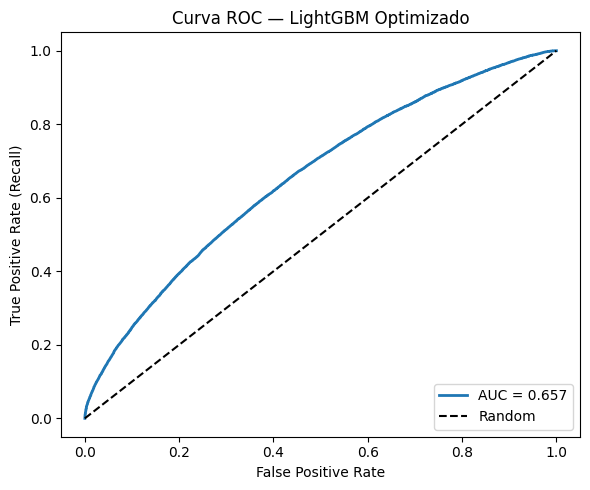

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_roc_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/roc_best_model.png"
)
plt.tight_layout()
plt.show()

## 3. Curva Precision-Recall

La Precision-Recall complementa a la ROC y es especialmente útil cuando hay desbalanceo de clases. Aquí muestra el compromiso entre detectar reingresos (recall) y que cuando se lanza una alerta sea de verdad un reingreso (precision). Si el área bajo la curva queda muy por encima de la prevalencia base (0,342), el modelo aporta algo más allá de adivinar.

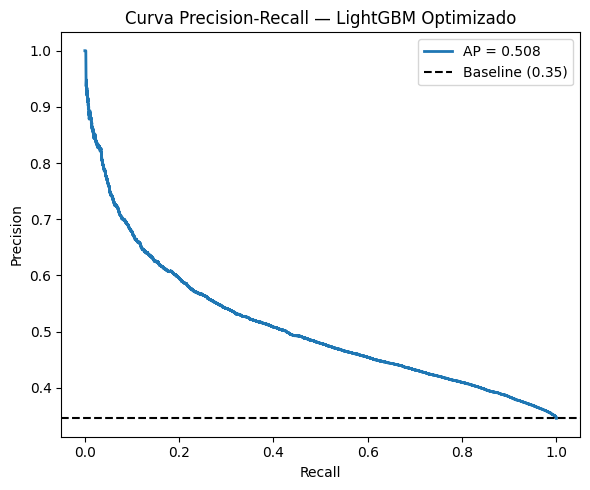

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_precision_recall_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/pr_curve_best_model.png"
)
plt.tight_layout()
plt.show()

## 4. Matriz de confusión y reporte de clasificación

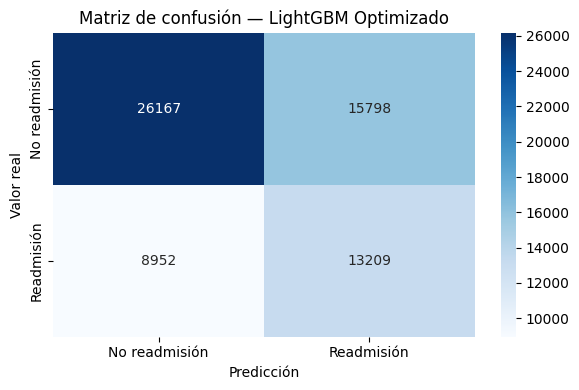

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion_matrix(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/confusion_matrix_best_model.png"
)
plt.tight_layout()
plt.show()

In [24]:
get_classification_report(best_model, X_test, y_test)

,precision,recall,f1-score,support
No readmisión,0.745,0.624,0.679,41965.000
Readmisión,0.455,0.596,0.516,22161.000
accuracy,0.614,0.614,0.614,0.614
macro avg,0.600,0.610,0.598,64126.000
weighted avg,0.645,0.614,0.623,64126.000


## 5. Importancia de variables

Aquí se mira en qué variables se apoya más el modelo. La importancia por ganancia da una idea rápida pero global y sin signo (solo dice "esta variable importa"); en la sección de SHAP se ve además la dirección del efecto. Vale como primera lectura de interpretabilidad.

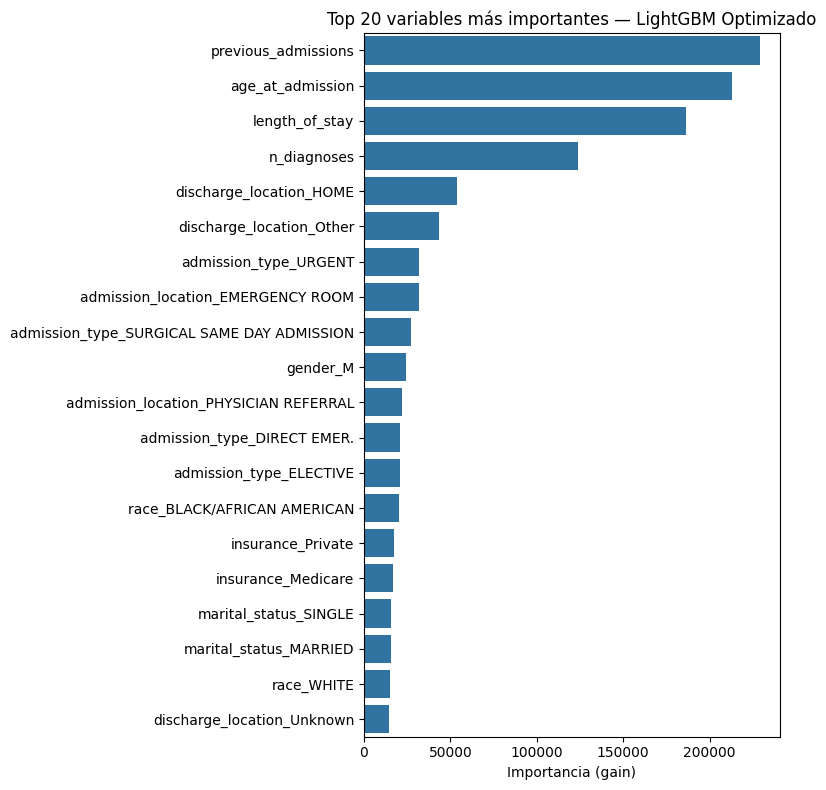

,feature,importance
2,previous_admissions,229242.920429
3,age_at_admission,213073.308481
0,length_of_stay,186134.693279
1,n_diagnoses,123671.519780
48,discharge_location_HOME,54013.276862
50,discharge_location_Other,43557.311626
37,admission_type_URGENT,31974.565609
39,admission_location_EMERGENCY ROOM,31931.435657
36,admission_type_SURGICAL SAME DAY ADMISSION,27143.492937
4,gender_M,24457.675219


In [25]:
importance_df = plot_feature_importance(
    best_model,
    feature_names=X_train.columns.tolist(),
    model_name=best_model_name,
    top_n=20,
    save_path="../results/feature_importance_best_model.png"
)
importance_df

## 6. Análisis de umbral de decisión

El umbral por defecto de 0,5 no tiene nada de mágico (es un valor estándar de las librerías, no una decisión clínica). En este caso conviene revisarlo: si la idea es usar el modelo como una herramienta de cribado para señalar pacientes a vigilar, vale la pena bajarlo y aceptar más falsos positivos a cambio de no dejar escapar reingresos reales.

Importante: el umbral óptimo se busca **sobre validación** y luego se evalúa con ese valor fijo sobre test. Si se eligiera mirando directamente las curvas del test, se estaría sobreajustando el umbral al conjunto de evaluación final, que es justo lo que hay que evitar.

=== Selección de umbral (conjunto de validación) ===


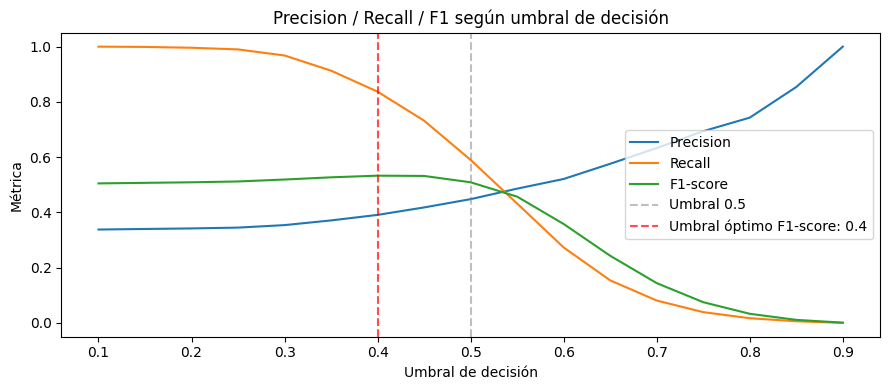


Umbral óptimo (F1-score): 0.4
Precision    0.391
Recall       0.837
F1-score     0.533

=== Evaluación del umbral óptimo (0.4) sobre test set ===

Comparación umbral 0.5 vs umbral óptimo (test set):
        Precision  Recall  F1-score
Umbral                             
0.5        0.4554  0.5960    0.5163
0.4        0.3997  0.8405    0.5418


,Precision,Recall,F1-score
Umbral,,,
0.5,0.4554,0.5960,0.5163
0.4,0.3997,0.8405,0.5418


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# primero buscamos el umbral óptimo en validación
print("=== Selección de umbral (conjunto de validación) ===")
threshold_df_val = threshold_analysis(best_model, X_val, y_val)
optimal_threshold = threshold_df_val["F1-score"].idxmax()

# lo evaluamos en test
print(f"\n=== Evaluación del umbral óptimo ({optimal_threshold}) sobre test set ===")
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)

results_threshold = {
    "Umbral":     optimal_threshold,
    "Precision":  round(precision_score(y_test, y_pred_optimal, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_optimal, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_optimal, zero_division=0), 4),
}

# comparamos con el umbral por defecto 0.5
y_pred_05 = (y_prob_test >= 0.5).astype(int)
results_default = {
    "Umbral":     0.5,
    "Precision":  round(precision_score(y_test, y_pred_05, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_05, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_05, zero_division=0), 4),
}

comparison = pd.DataFrame([results_default, results_threshold]).set_index("Umbral")
print("\nComparación umbral 0.5 vs umbral óptimo (test set):")
print(comparison.to_string())
comparison

## 7. Calibración, Brier Score y ECE

Una cosa es que el modelo *ordene* bien el riesgo (eso lo dice el AUC) y otra muy distinta es que las probabilidades que devuelve sean creíbles. Si predice un 70 % de probabilidad de reingreso para un grupo de pacientes, lo razonable es que aproximadamente 7 de cada 10 acaben reingresando. Si no, las probabilidades no son aprovechables como score de riesgo individual.

Para comprobarlo me apoyo en tres cosas:

- la **curva de calibración** (reliability diagram), que enseña visualmente si el modelo sobre- o subestima el riesgo en cada tramo de probabilidad
- el **Brier Score**, que es el error cuadrático medio entre la probabilidad predicha y la etiqueta real (mezcla calibración y discriminación en un solo número)
- el **ECE** (Expected Calibration Error), que aísla la parte de calibración: cuánto se aleja en promedio la probabilidad predicha del porcentaje real de positivos en cada bin

Lo ideal es que el modelo gane al baseline (predecir siempre la prevalencia). Si no lo gana (spoiler) toca recalibrar.

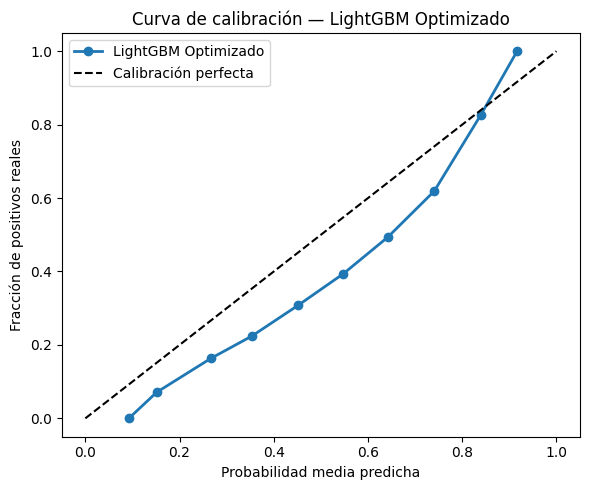


Brier Score:  0.2289
Baseline:     0.2262  (prediciendo siempre la prevalencia)
Mejora:       -0.0028


0.22890750664513818

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/calibration_best_model.png"
)
plt.tight_layout()
plt.show()

print()
brier_score(best_model, X_test, y_test)

In [28]:
expected_calibration_error(best_model, X_test, y_test, n_bins=10)

ECE (Expected Calibration Error): 0.1381
ECE baseline (prevalencia fija):  0.0993
Número de bins:                   10


0.1381482855414491

### 7.2 Postcalibración isotónica

Como el ECE del modelo sale por encima del baseline (sobreestima el riesgo de forma sistemática), pruebo a corregirlo con **regresión isotónica**. La isotónica es la elección habitual cuando no se quiere asumir una forma concreta para la función de calibración (solo le pide ser monótona no decreciente).

Detalle metodológico importante: el ajuste de la calibración se hace **sobre el conjunto de validación**, nunca sobre test. Si se hiciera sobre test, las métricas posteriores estarían infladas. Después se evalúa el modelo calibrado sobre test, igual que se hizo con el original.

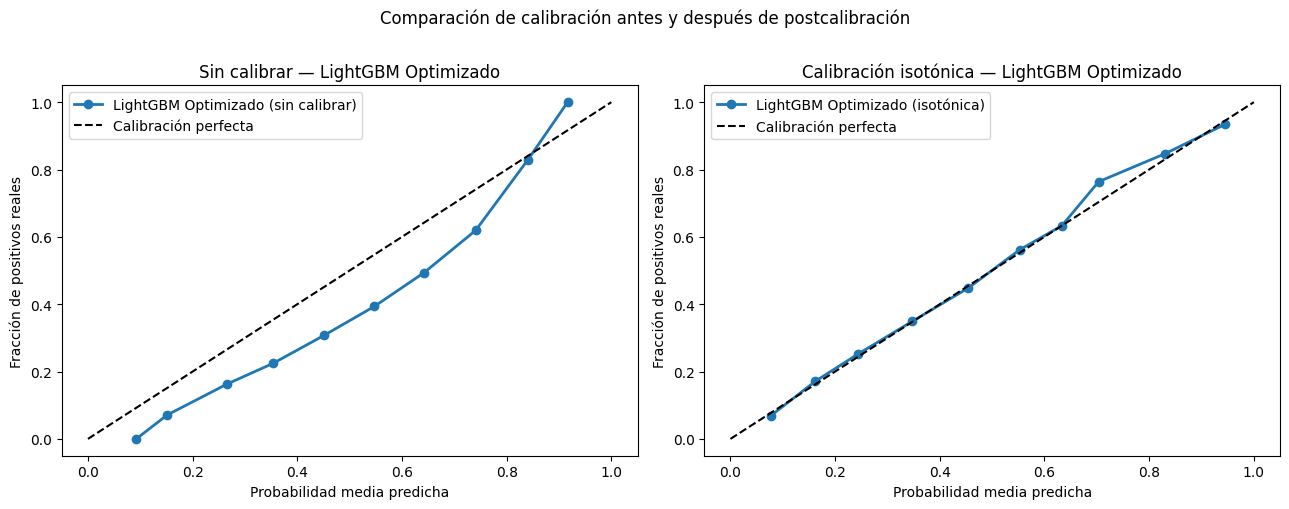

=== Métricas de calibración en test set ===

Modelo sin calibrar:
Brier Score:  0.2289
Baseline:     0.2262  (prediciendo siempre la prevalencia)
Mejora:       -0.0028
ECE (Expected Calibration Error): 0.1381
ECE baseline (prevalencia fija):  0.0993
Número de bins:                   10

Modelo con calibración isotónica:
Brier Score:  0.2095
Baseline:     0.2262  (prediciendo siempre la prevalencia)
Mejora:       0.0167
ECE (Expected Calibration Error): 0.0065
ECE baseline (prevalencia fija):  0.0933
Número de bins:                   10

Resumen:
  Brier Score:  0.2289 → 0.2095  (delta -0.0194)
  ECE:          0.1381 → 0.0065  (delta -0.1316)
Modelo calibrado guardado en models/lightgbm_calibrated.pkl


In [29]:
import numpy as np
from sklearn.isotonic import IsotonicRegression

# ajustamos la calibración isotónica sobre validación, nunca sobre test
y_val_proba = best_model.predict_proba(X_val)[:, 1]
ir = IsotonicRegression(out_of_bounds="clip")
ir.fit(y_val_proba, y_val)

class _CalibratedWrapper:
    """Wrapper para aplicar calibración isotónica al modelo."""
    def __init__(self, base_model, ir):
        self.base_model = base_model
        self.ir = ir
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.ir.predict(raw)
        return np.column_stack([1 - cal, cal])

calibrated_model = _CalibratedWrapper(best_model, ir)

# comparamos las curvas antes y después de calibrar
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=f"{best_model_name} (sin calibrar)",
    ax=axes[0],
)
axes[0].set_title(f"Sin calibrar — {best_model_name}")

plot_calibration_curve(
    calibrated_model, X_test, y_test,
    model_name=f"{best_model_name} (isotónica)",
    ax=axes[1],
    save_path="../results/calibration_isotonic.png",
)
axes[1].set_title(f"Calibración isotónica — {best_model_name}")

plt.suptitle("Comparación de calibración antes y después de postcalibración", y=1.01)
plt.tight_layout()
plt.savefig("../results/calibration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# métricas comparativas en test
print("=== Métricas de calibración en test set ===\n")
print("Modelo sin calibrar:")
bs_base  = brier_score(best_model, X_test, y_test)
ece_base = expected_calibration_error(best_model, X_test, y_test, n_bins=10)

print("\nModelo con calibración isotónica:")
bs_cal  = brier_score(calibrated_model, X_test, y_test)
ece_cal = expected_calibration_error(calibrated_model, X_test, y_test, n_bins=10)

print(f"\nResumen:")
print(f"  Brier Score:  {bs_base:.4f} → {bs_cal:.4f}  (delta {bs_cal - bs_base:+.4f})")
print(f"  ECE:          {ece_base:.4f} → {ece_cal:.4f}  (delta {ece_cal - ece_base:+.4f})")

# guardamos el modelo calibrado por si hace falta después
import joblib
joblib.dump(calibrated_model, "../models/lightgbm_calibrated.pkl")
print("Modelo calibrado guardado en models/lightgbm_calibrated.pkl")

## 8. Decision Curve Analysis (DCA)

Hasta aquí todas las métricas miden cosas distintas (discriminación, calibración, recall) pero ninguna responde a la pregunta que de verdad importa en clínica: **¿usar este modelo aporta algo respecto a no usarlo?**.

La DCA es la forma estándar de contestar a eso. Calcula el "beneficio neto" del modelo a diferentes umbrales y lo compara con dos estrategias muy simples: intervenir sobre todos los pacientes (asumir que todos reingresan y actuar en consecuencia) o no intervenir sobre ninguno. Si la curva del modelo queda por encima de las dos en algún rango de umbrales, en ese rango usarlo merece la pena.

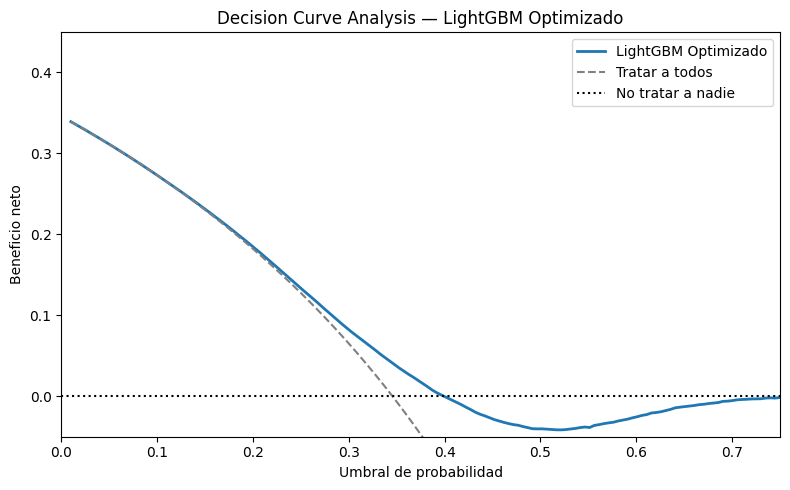

,threshold,net_benefit_model,net_benefit_all
0,0.010000,0.338975,0.338975
1,0.014966,0.335642,0.335642
2,0.019933,0.332276,0.332276
3,0.024899,0.328875,0.328875
4,0.029866,0.325439,0.325439
5,0.034832,0.321968,0.321968
6,0.039799,0.318461,0.318461
7,0.044765,0.314917,0.314917
8,0.049732,0.311337,0.311337
9,0.054698,0.307719,0.307719


In [30]:
dca_df = plot_dca(
    best_model, X_test, y_test,
    model_name=best_model_name,
    save_path="../results/dca_best_model.png"
)
dca_df.head(10)

### 8.2 DCA con probabilidades calibradas

La DCA anterior usa las probabilidades sin calibrar, así que los umbrales no se interpretan directamente como "probabilidad real de reingreso". Repito el análisis con las probabilidades postcalibradas para que el eje X pase a tener una lectura clínica clara (un umbral de 0,3 quiere decir "intervenir cuando el modelo estima un 30 % real de probabilidad de reingreso").

In [ ]:
# calibrated_model viene de la celda 7.2 (ya está ajustado sobre validación);
# no hace falta volver a entrenar la isotónica ni redefinir el wrapper.

thresholds = np.linspace(0.01, 0.75, 150)
y_prob_raw = best_model.predict_proba(X_test)[:, 1]
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
n_test = len(y_test)
prev = y_test.mean()

nb_raw, nb_cal, nb_all_arr = [], [], []
for t in thresholds:
    tp_r = ((y_prob_raw >= t) & (y_test == 1)).sum()
    fp_r = ((y_prob_raw >= t) & (y_test == 0)).sum()
    tp_c = ((y_prob_cal >= t) & (y_test == 1)).sum()
    fp_c = ((y_prob_cal >= t) & (y_test == 0)).sum()
    nb_raw.append(tp_r / n_test - (t / (1 - t)) * fp_r / n_test)
    nb_cal.append(tp_c / n_test - (t / (1 - t)) * fp_c / n_test)
    nb_all_arr.append(prev - (t / (1 - t)) * (1 - prev))

nb_raw, nb_cal, nb_all_arr = map(np.array, [nb_raw, nb_cal, nb_all_arr])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, nb_raw, label="LightGBM (sin calibrar)", linewidth=2)
ax.plot(thresholds, nb_cal, label="LightGBM (calibrado)", linewidth=2, linestyle="--", color="green")
ax.plot(thresholds, nb_all_arr, label="Tratar a todos", linestyle=":", color="gray")
ax.axhline(0, color="black", linestyle="-.", linewidth=0.8, label="No tratar a nadie")
ax.set_xlabel("Umbral de probabilidad")
ax.set_ylabel("Beneficio neto")
ax.set_title("DCA: probabilidades sin calibrar vs calibradas")
ax.legend()
ax.set_xlim(0, 0.75)
ax.set_ylim(-0.05, prev * 1.3)
plt.tight_layout()
plt.savefig("../results/dca_comparison_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()

# Rango de utilidad clínica neta
ref = np.maximum(nb_all_arr, 0)
print("Rango umbral con NB>ref — sin calibrar:",
      f"{thresholds[nb_raw > ref].min():.2f}–{thresholds[nb_raw > ref].max():.2f}"
      if any(nb_raw > ref) else "ninguno")
print("Rango umbral con NB>ref — calibrado:   ",
      f"{thresholds[nb_cal > ref].min():.2f}–{thresholds[nb_cal > ref].max():.2f}"
      if any(nb_cal > ref) else "ninguno")


## 9. Interpretabilidad SHAP

La importancia por ganancia que se vio en la sección 5 es útil pero limitada (solo dice qué variables pesan más en promedio, sin decir en qué dirección). SHAP completa la foto: para cada predicción concreta, descompone la salida del modelo en la contribución de cada variable.

Los valores SHAP tienen signo: un valor positivo empuja la predicción hacia "reingreso", uno negativo hacia "no reingreso". Eso da dos vistas distintas:

- **global** (beeswarm): se ve qué variables influyen más en el conjunto del test y en qué dirección (¿más edad sube o baja el riesgo? ¿más diagnósticos previos hace que el modelo prediga más reingreso?)
- **local** (waterfall, en la siguiente sección): para un paciente concreto, qué variables están tirando hacia arriba o hacia abajo

Lo calculo sobre una muestra de 2 000 registros porque sobre los 64 000 del test el coste computacional es bastante alto y la imagen resultante no cambia significativamente.

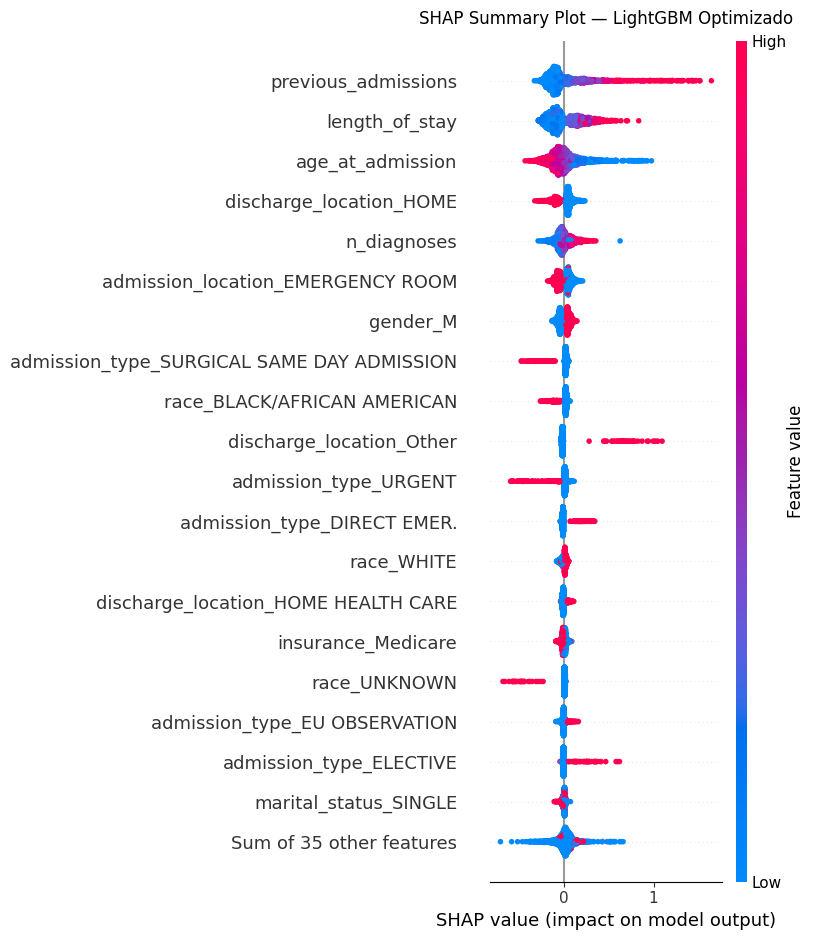

,feature,mean_abs_shap
0,previous_admissions,0.170600
1,length_of_stay,0.148140
2,age_at_admission,0.124556
3,discharge_location_HOME,0.073422
4,n_diagnoses,0.063596
5,admission_location_EMERGENCY ROOM,0.059322
6,gender_M,0.048548
7,admission_type_SURGICAL SAME DAY ADMISSION,0.041903
8,race_BLACK/AFRICAN AMERICAN,0.036155
9,discharge_location_Other,0.033292


In [32]:
X_sample = X_test.sample(n=2000, random_state=42)

shap_df = plot_shap_summary(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=20,
    save_path="../results/shap_summary_best_model.png"
)
shap_df

### 9.2 Explicación local: waterfall plots

El beeswarm anterior es bonito pero es un resumen global. Para entender cómo trabaja el modelo en casos concretos, miro dos *waterfall plots*: el del paciente con mayor probabilidad predicha y el del de menor probabilidad de la muestra. En cada uno, las barras indican cuánto está empujando cada variable hacia arriba o hacia abajo respecto a la predicción base del modelo.

Este tipo de visualización es la más útil en clínica (un médico no se va a leer un beeswarm, pero sí puede entender "este paciente saca alta probabilidad porque tiene 7 ingresos previos, 18 diagnósticos y un alta a centro de cuidados").

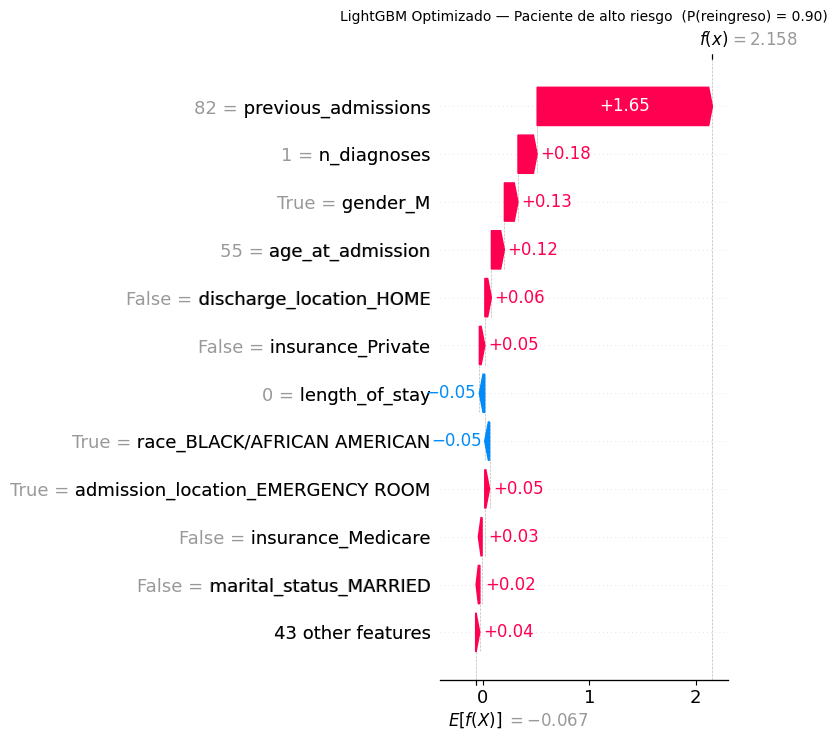

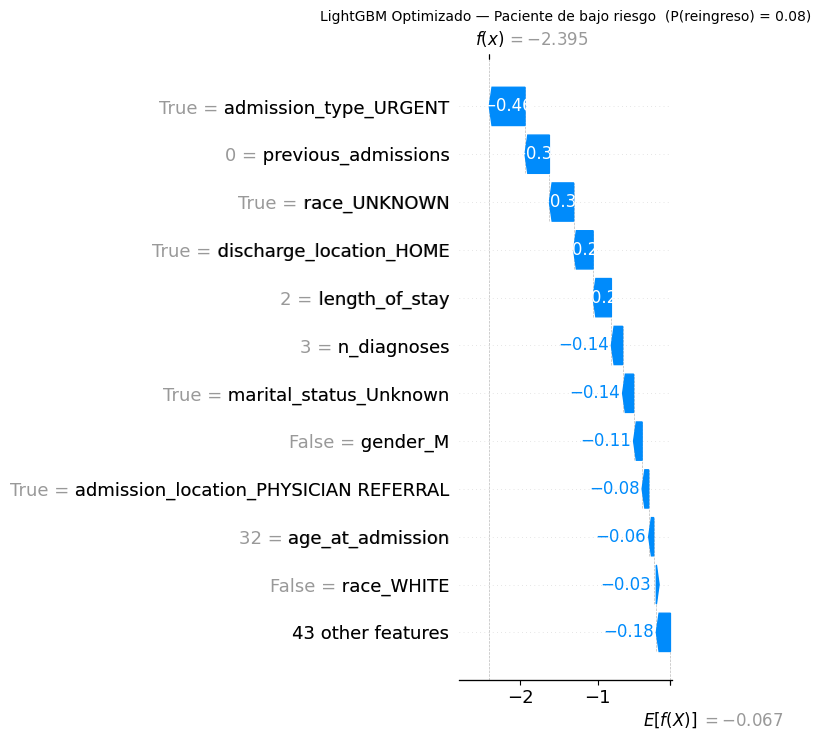

{'idx_high': 1856, 'idx_low': 1891, 'prob_high': 0.896, 'prob_low': 0.084}


In [33]:
waterfall_info = plot_shap_waterfall(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=12,
    save_path_high="../results/shap_waterfall_high_risk.png",
    save_path_low="../results/shap_waterfall_low_risk.png",
)
print(waterfall_info)


## 10. Intervalos de confianza Bootstrap

Reportar un AUC sin intervalo de confianza es como dar una temperatura sin decir si es la media del día o la máxima (la cifra suelta dice poco). Aquí saco los IC95 % de las métricas principales por bootstrap percentil con 1 000 remuestreos sobre el test set.

Notas:

- el bootstrap se hace **solo** sobre el test set, no se vuelve a entrenar el modelo en cada iteración
- el umbral óptimo (0,40) se fijó en su momento sobre validación; recall y demás métricas dependientes del umbral se calculan en cada remuestreo con ese mismo valor fijo, para que el bootstrap refleje la variabilidad de la población de test y no la del proceso de selección del umbral

In [34]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

RNG = np.random.default_rng(42)
N_BOOT = 1000
OPT_THRESH = 0.40  # fijado sobre validación por max F1

y_prob_test = best_model.predict_proba(X_test)[:, 1]
n = len(y_test)

aucs, aps, recs = [], [], []
for _ in range(N_BOOT):
    idx = RNG.integers(0, n, size=n)
    yt = y_test.iloc[idx]
    yp = y_prob_test[idx]
    if yt.nunique() < 2:
        continue
    aucs.append(roc_auc_score(yt, yp))
    aps.append(average_precision_score(yt, yp))
    recs.append(recall_score(yt, (yp >= OPT_THRESH).astype(int), zero_division=0))

lo, hi = 2.5, 97.5
point_auc = roc_auc_score(y_test, y_prob_test)
point_ap  = average_precision_score(y_test, y_prob_test)
point_rec = recall_score(y_test, (y_prob_test >= OPT_THRESH).astype(int), zero_division=0)

print("=== Intervalos de confianza Bootstrap IC95% (n=1.000) ===\n")
print(f"ROC-AUC : {point_auc:.3f}  [{np.percentile(aucs, lo):.3f}, {np.percentile(aucs, hi):.3f}]")
print(f"AP      : {point_ap:.3f}  [{np.percentile(aps,  lo):.3f}, {np.percentile(aps,  hi):.3f}]")
print(f"Recall  : {point_rec:.3f}  [{np.percentile(recs, lo):.3f}, {np.percentile(recs, hi):.3f}]  (umbral={OPT_THRESH})")
print(f"\nTest set: {n:,} registros · Umbral óptimo fijado sobre validación")

=== Intervalos de confianza Bootstrap IC95% (n=1.000) ===

ROC-AUC : 0.657  [0.652, 0.661]
AP      : 0.508  [0.502, 0.515]
Recall  : 0.841  [0.836, 0.846]  (umbral=0.4)

Test set: 64,126 registros · Umbral óptimo fijado sobre validación


## 11. Conclusiones

Resumen de lo visto sobre el LightGBM optimizado:

- **Discriminación**: AUC 0,657 (IC95 % 0,652–0,661), Average Precision 0,508. Está dentro del rango que reporta la literatura para reingreso a 30 días con variables administrativas (LACE+: 0,63–0,72), así que no es un mal resultado dado el conjunto de datos disponible.
- **Importancia de variables y SHAP**: el modelo se apoya sobre todo en `previous_admissions`, `length_of_stay`, `age_at_admission` y la categoría de `discharge_location`. Coincide con lo que se sabe del problema clínicamente, lo cual al menos da confianza en que el modelo está aprendiendo señales razonables.
- **Umbral**: con el umbral por defecto (0,5) el recall se queda en 59,6 %, lo cual para un cribado es flojo. Bajándolo a 0,40 (que es el óptimo en F1 sobre validación) el recall sube al 84,1 % a costa de bajar la precision a 39,9 %. En contexto clínico el trade-off probablemente vale la pena.
- **Calibración**: el modelo sin calibrar sobreestima el riesgo (ECE = 0,1381, baseline = 0,099). Aplicando regresión isotónica sobre validación, ECE baja a 0,007 y Brier de 0,229 a 0,209. El modelo calibrado se guarda en `models/lightgbm_calibrated.pkl` y es el que debe usarse cuando las probabilidades se interpreten como score individual.
- **DCA**: el modelo aporta beneficio neto frente a "tratar a todos" o "no tratar a nadie" en el rango de umbrales 0,04–0,38 aproximadamente. Fuera de ese rango no hay ventaja.

**Sobre el split**: los datos se dividen por paciente (`GroupShuffleSplit`), así que no hay leakage entre admisiones del mismo `subject_id`. Comparando con la división aleatoria por admisión, las métricas varían menos de 0,002 en AUC (el modelo aprende patrones generalizables, no atajos de "recordar" al paciente).